In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [16]:
df = pd.read_csv('Sample - Superstore.csv', encoding="latin1")

In [17]:
df.shape

(9994, 21)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [19]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


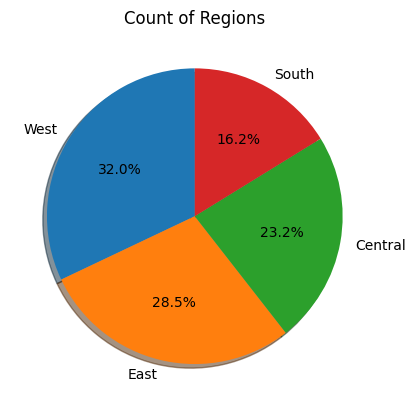

In [72]:
Region_order=df['Region'].value_counts()
plt.pie(
    Region_order.values,
    labels=Region_order.index,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
plt.title('Count of Regions')
plt.show()

In [ ]:
# The West region accounts for the highest proportion of orders (32%), indicating it is the store's strongest market by order volume.
# The South region contributes the fewest orders (16.2%), suggesting lower customer activity compared to the other regions.

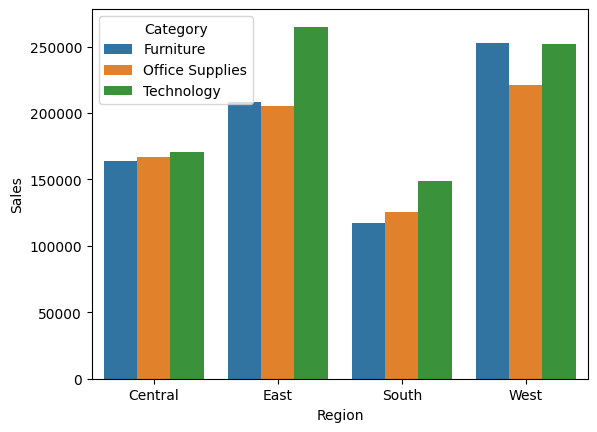

In [36]:
region_category = df.groupby(['Region','Category'])['Sales'].sum().reset_index()

sns.barplot(
    data=region_category,
    x='Region',
    y='Sales',
    hue='Category'
)
plt.show()

In [ ]:
# The West region generates the highest total sales, with Furniture contributing the largest share of sales in the region.
# The East region also performs strongly, with Technology being its highest-selling category.
# The South region records the lowest sales across all product categories, indicating potential opportunities for business growth.

In [37]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

<Axes: xlabel='Segment', ylabel='Sales'>

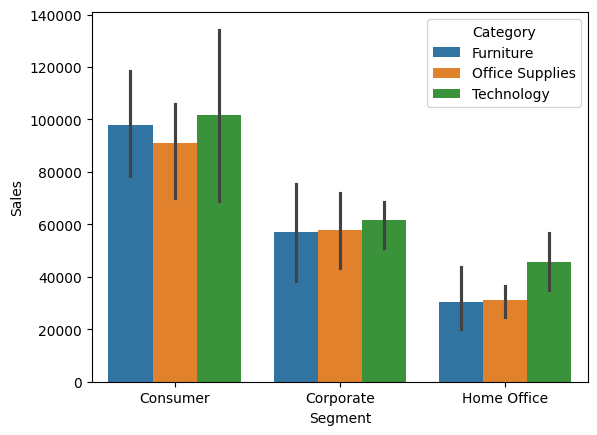

In [39]:
Segment_category=df.groupby(['Segment','Category'])['Sales'].sum().reset_index()
sns.barplot(
    data=Segment_category,
    x='Segment',
    y='Sales',
    hue='Category'
)

In [ ]:
# The Consumer segment is the company's largest revenue-generating customer segment.
# Technology products are the strongest-performing category across all customer segments,
# indicating consistently high customer demand for technology products.

In [40]:
df['City'].unique()

array(['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord',
       'Seattle', 'Fort Worth', 'Madison', 'West Jordan', 'San Francisco',
       'Fremont', 'Philadelphia', 'Orem', 'Houston', 'Richardson',
       'Naperville', 'Melbourne', 'Eagan', 'Westland', 'Dover',
       'New Albany', 'New York City', 'Troy', 'Chicago', 'Gilbert',
       'Springfield', 'Jackson', 'Memphis', 'Decatur', 'Durham',
       'Columbia', 'Rochester', 'Minneapolis', 'Portland', 'Saint Paul',
       'Aurora', 'Charlotte', 'Orland Park', 'Urbandale', 'Columbus',
       'Bristol', 'Wilmington', 'Bloomington', 'Phoenix', 'Roseville',
       'Independence', 'Pasadena', 'Newark', 'Franklin', 'Scottsdale',
       'San Jose', 'Edmond', 'Carlsbad', 'San Antonio', 'Monroe',
       'Fairfield', 'Grand Prairie', 'Redlands', 'Hamilton', 'Westfield',
       'Akron', 'Denver', 'Dallas', 'Whittier', 'Saginaw', 'Medina',
       'Dublin', 'Detroit', 'Tampa', 'Santa Clara', 'Lakeville',
       'San Diego', 'Brentwood', 'Cha

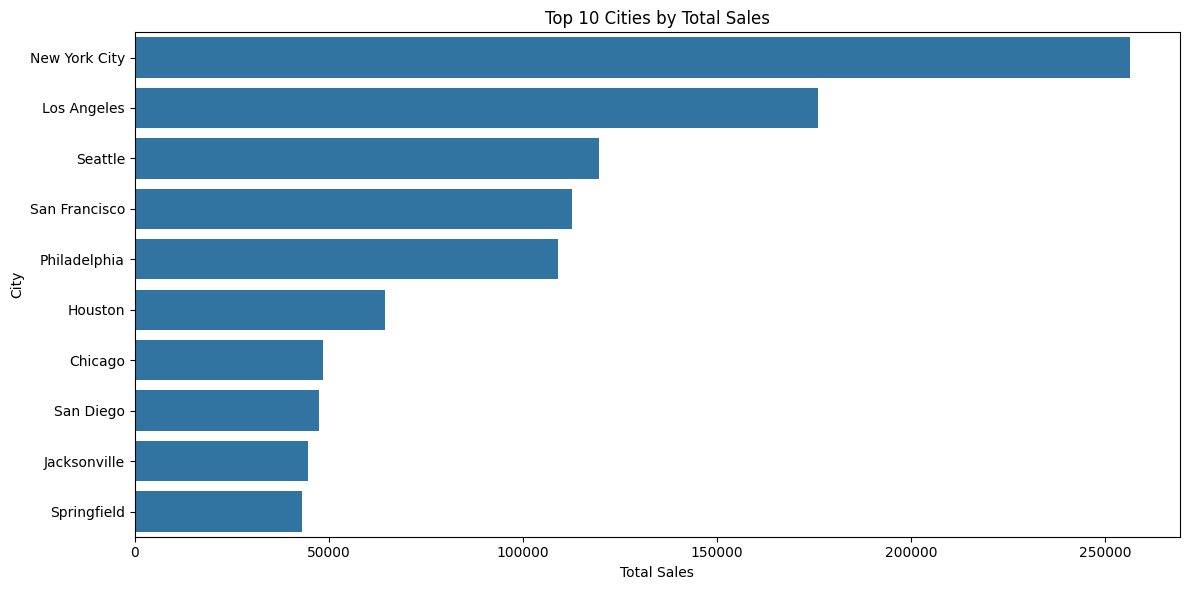

In [55]:
top_city = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_city,
    x='Sales',
    y='City'
)

plt.title("Top 10 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [ ]:
# New York City is the company's strongest revenue-generating market.
# The consistently high sales in New York City and Los Angeles indicate strong customer demand,
# making these cities ideal for inventory expansion, premium product launches, and targeted marketing campaigns.

In [57]:
df['Ship_Year'] = pd.to_datetime(df['Ship Date']).dt.year
df['Ship_Month'] = pd.to_datetime(df['Ship Date']).dt.month_name()

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

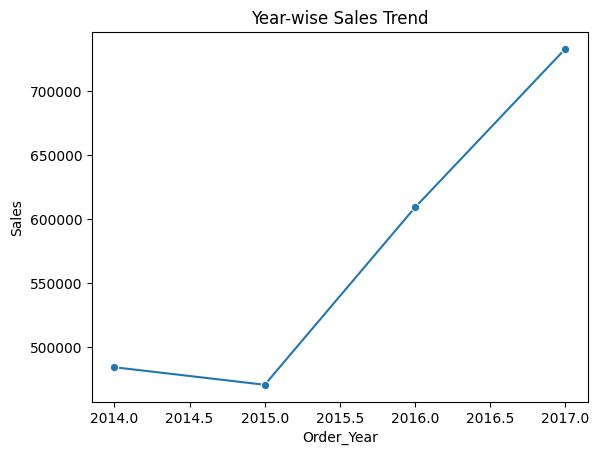

In [60]:
df['Order_Year'] = pd.to_datetime(df['Order Date']).dt.year

year_sales = (
    df.groupby('Order_Year')['Sales']
      .sum()
      .reset_index()
)

sns.lineplot(
    data=year_sales,
    x='Order_Year',
    y='Sales',
    marker='o'
)

plt.title("Year-wise Sales Trend")
plt.show()

In [ ]:
# The business experienced consistent growth between 2014 and 2017.
# Before concluding that sales declined in 2018, it is important to verify whether the dataset contains complete data for that year,
#  as partial-year data can produce an artificially low total.

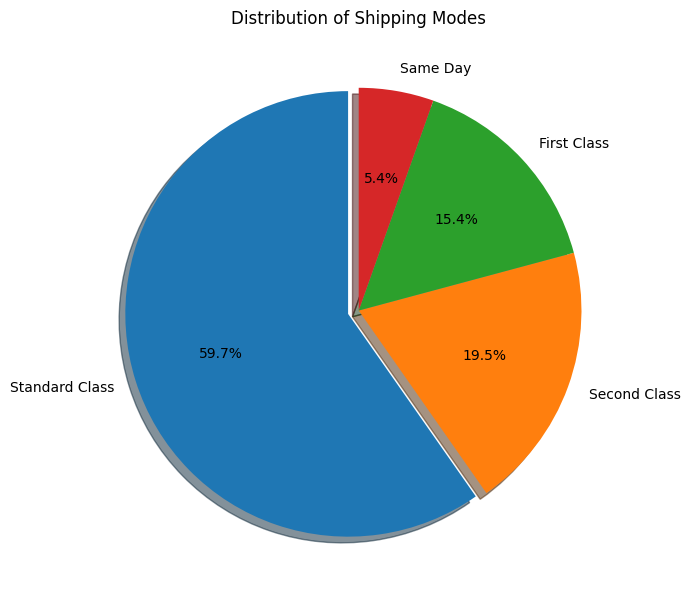

In [64]:
Region_order = df['Ship Mode'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    Region_order.values,
    labels=Region_order.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.05,0,0,0]
)

plt.title("Distribution of Shipping Modes")
plt.tight_layout()
plt.show()

In [ ]:
# Customers strongly prefer the Standard Class shipping mode, indicating that cost-effective delivery is more popular than faster shipping options.
# Same Day delivery has the lowest adoption, suggesting it is used only for urgent orders or by a smaller customer segment.

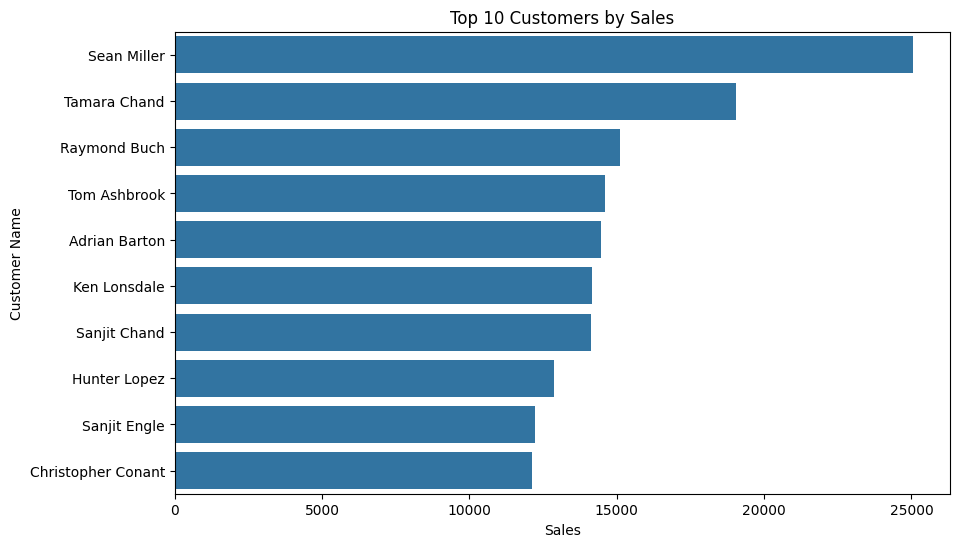

In [66]:
top_customer = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customer,
    x='Sales',
    y='Customer Name'
)

plt.title("Top 10 Customers by Sales")
plt.show()

In [ ]:
# A small group of customers generates a large share of total sales.
# These high-value customers are important for the business and should be prioritized through customer retention programs, loyalty rewards,
#  and personalized marketing campaigns.

In [70]:
df['Sub-Category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

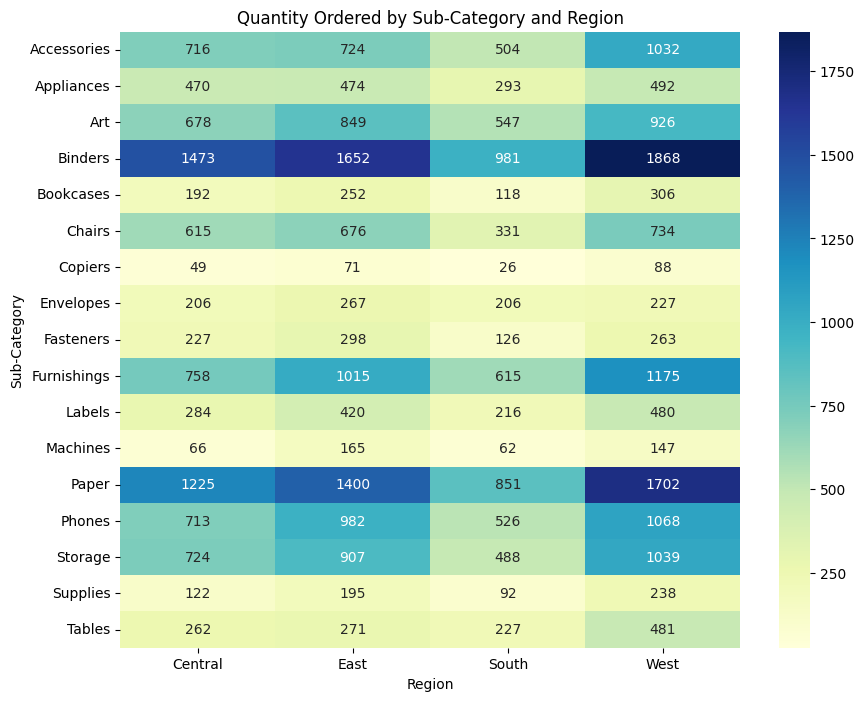

In [71]:
pivot = pd.pivot_table(
    df,
    values='Quantity',
    index='Sub-Category',
    columns='Region',
    aggfunc='sum'
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Quantity Ordered by Sub-Category and Region")
plt.show()

In [ ]:
# The West region is the strongest-performing market in terms of product demand.
# High-demand sub-categories such as Binders, Paper, Phones, and
# Storage should be stocked adequately in this region to prevent inventory shortages and maintain customer satisfaction.

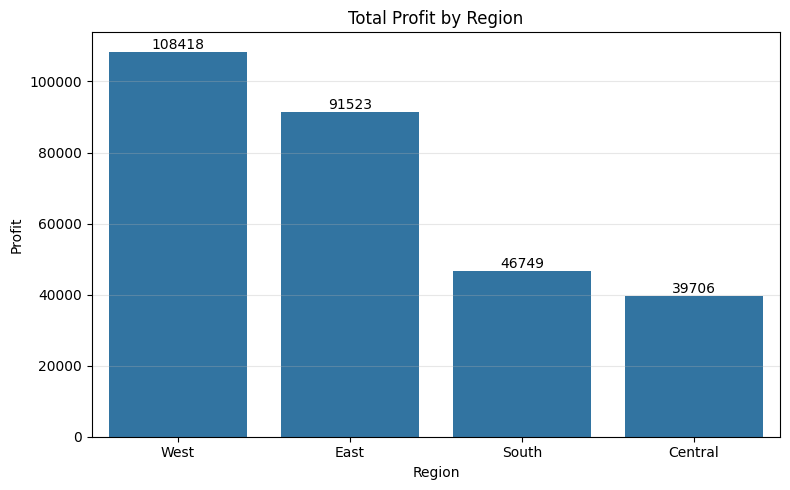

In [73]:
region_profit = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=region_profit,
    x='Region',
    y='Profit'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# The region generating the highest profit contributes the most to the company's overall profitability.
#  Regions with lower profits should be analyzed for pricing, product mix, or operational improvements.

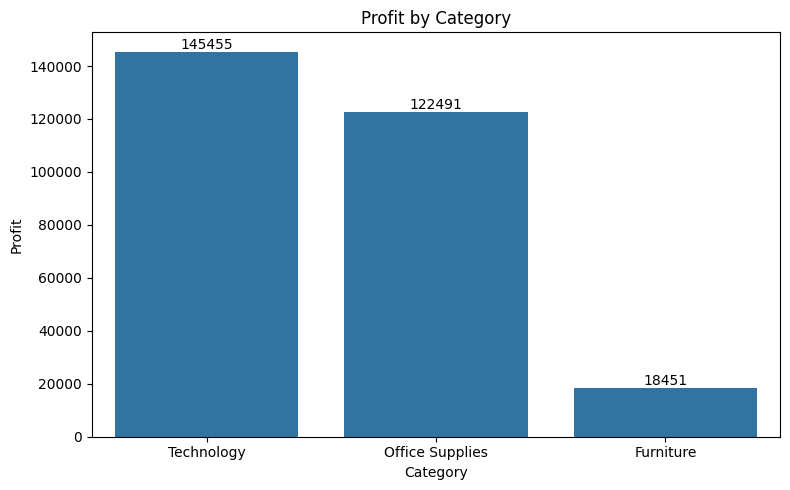

In [74]:
category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=category_profit,
    x='Category',
    y='Profit'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [ ]:
# Categories with strong profits should receive continued investment,
# while lower-profit categories should be evaluated to improve margins through pricing, sourcing, or product strategy.

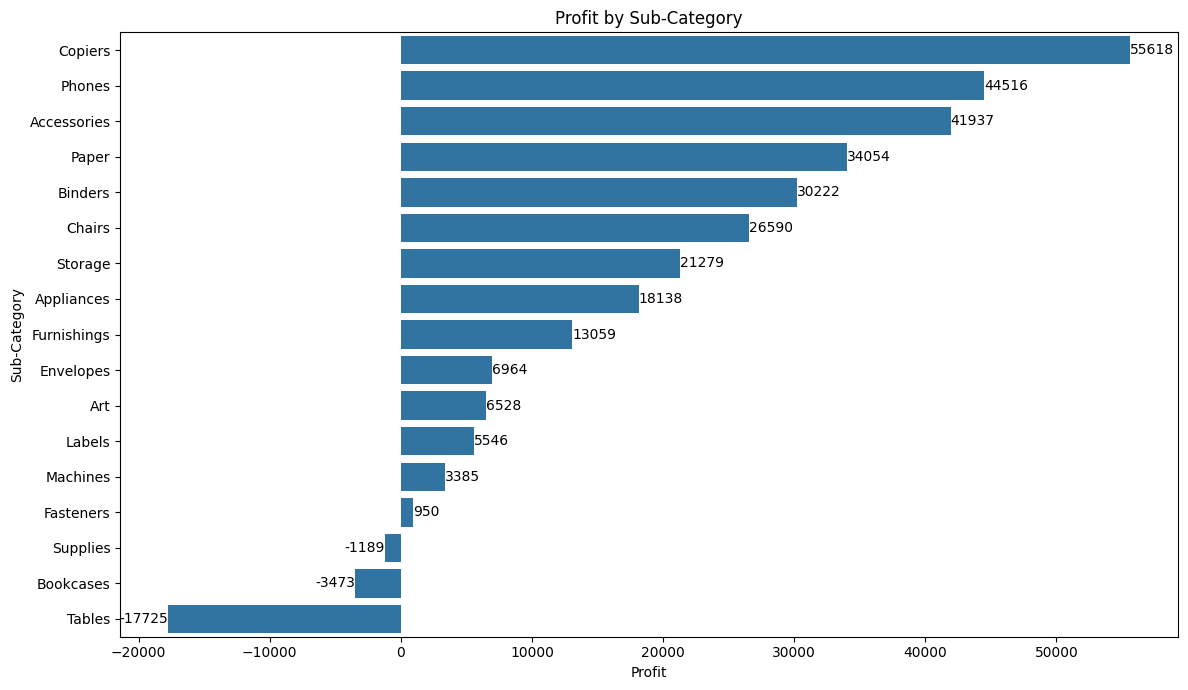

In [75]:
subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=subcategory_profit,
    x='Profit',
    y='Sub-Category'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [76]:
loss = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values()
)

print(loss.head())

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64


In [ ]:
# Some sub-categories may generate strong sales but low or even negative profit.
# These products should be reviewed for pricing, discount policies, and procurement costs to improve overall profitability.